In [8]:
import numpy as np
import nibabel as nib
from matplotlib.widgets import Slider
import ipywidgets as widgets
from IPython.display import display
from scipy.ndimage import zoom

import matplotlib.pyplot as plt

def visualize_nii_images(nii_file_path, num_frames=None, num_channels=None, size=None, rgb_mode=True):
    """
    Visualize all images in a NIfTI file with interactive controls
    
    Parameters:
    nii_file_path: path to the .nii or .nii.gz file
    num_frames: number of time frames (optional, will be detected from file)
    num_channels: number of channels (optional, will be detected from file)
    size: tuple of (height, width) for resizing (optional)
    rgb_mode: if True and data has 3 channels, display as RGB image
    """
    
    # Load the NIfTI file
    nii_img = nib.load(nii_file_path)
    data = nii_img.get_fdata()
    
    print(f"Original data shape: {data.shape}")
    
    # Handle different data dimensions
    # Data format: (frames, channels, height, width)
    if len(data.shape) == 3:  # 3D volume (height, width, slices)
        data = data[:, :, :, np.newaxis]  # Add time dimension
    elif len(data.shape) == 4:  # 4D volume (frames, channels, height, width)
        frames, channels, height, width = data.shape
    elif len(data.shape) == 5:  # 5D volume - reshape to 4D
        data = data.reshape(-1, *data.shape[-3:])
        frames, channels, height, width = data.shape
    
    # Get dimensions based on current data format
    if len(data.shape) == 4:
        frames, channels, height, width = data.shape
    else:
        height, width, slices = data.shape[:3]
        frames = data.shape[3] if len(data.shape) > 3 else 1
        channels = 1
    
    print(f"Processed data shape: {data.shape}")
    print(f"Frames: {frames}, Channels: {channels}, Height: {height}, Width: {width}")
    
    # Check if RGB mode is applicable
    use_rgb = rgb_mode and channels == 3
    
    # Create interactive visualization
    def create_interactive_viewer():
        # Create frame slider
        frame_slider = widgets.IntSlider(
            value=0,
            min=0,
            max=frames-1,
            description='Frame:',
            continuous_update=False
        )
        
        # Create channel slider (only if not using RGB mode)
        if not use_rgb:
            channel_slider = widgets.IntSlider(
                value=0,
                min=0,
                max=channels-1,
                description='Channel:',
                continuous_update=False
            )
        
        # Plotting function
        def plot_slice(frame_idx=0, channel_idx=0):
            fig, ax = plt.subplots(1, 1, figsize=(8, 8))
            
            if use_rgb:
                # Merge channels for RGB display: data[frame, :, height, width] -> (height, width, 3)
                img_slice = data[frame_idx, :, :, :].transpose(1, 2, 0)  # (3, H, W) -> (H, W, 3)
                
                # Normalize to 0-1 range for RGB display
                img_slice = img_slice - img_slice.min()
                if img_slice.max() > 0:
                    img_slice = img_slice / img_slice.max()
                
                # Resize if requested
                if size is not None:
                    zoom_factors = (size[0]/img_slice.shape[0], size[1]/img_slice.shape[1], 1)
                    img_slice = zoom(img_slice, zoom_factors)
                
                im = ax.imshow(img_slice, origin='lower')
                ax.set_title(f'RGB Image - Frame: {frame_idx}')
            else:
                # Single channel display: data[frame, channel, height, width]
                img_slice = data[frame_idx, channel_idx, :, :]
                
                # Resize if requested
                if size is not None:
                    zoom_factors = (size[0]/img_slice.shape[0], size[1]/img_slice.shape[1])
                    img_slice = zoom(img_slice, zoom_factors)
                
                im = ax.imshow(img_slice, cmap='gray', origin='lower')
                ax.set_title(f'Frame: {frame_idx}, Channel: {channel_idx}')
                plt.colorbar(im)
            
            ax.axis('off')
            plt.tight_layout()
            plt.show()
        
        # Create interactive widget based on mode
        if use_rgb:
            interactive_plot = widgets.interactive(
                plot_slice,
                frame_idx=frame_slider
            )
        else:
            interactive_plot = widgets.interactive(
                plot_slice,
                frame_idx=frame_slider,
                channel_idx=channel_slider
            )
        
        display(interactive_plot)
    
    # Alternative: Grid view of multiple frames
    def show_grid_view(channel_idx=0, rows=4, cols=4):
        fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
        axes = axes.flatten()
        
        frame_step = max(1, frames // (rows * cols))
        
        for i, ax in enumerate(axes):
            frame_idx = i * frame_step
            if frame_idx < frames:
                if use_rgb:
                    # RGB display
                    img_slice = data[frame_idx, :, :, :].transpose(1, 2, 0)  # (3, H, W) -> (H, W, 3)
                    
                    # Normalize to 0-1 range
                    img_slice = img_slice - img_slice.min()
                    if img_slice.max() > 0:
                        img_slice = img_slice / img_slice.max()
                    
                    # Resize if requested
                    if size is not None:
                        zoom_factors = (size[0]/img_slice.shape[0], size[1]/img_slice.shape[1], 1)
                        img_slice = zoom(img_slice, zoom_factors)
                    
                    ax.imshow(img_slice, origin='lower')
                    ax.set_title(f'RGB Frame {frame_idx}')
                else:
                    # Single channel display
                    img_slice = data[frame_idx, channel_idx, :, :]
                    
                    # Resize if requested
                    if size is not None:
                        zoom_factors = (size[0]/img_slice.shape[0], size[1]/img_slice.shape[1])
                        img_slice = zoom(img_slice, zoom_factors)
                    
                    ax.imshow(img_slice, cmap='gray', origin='lower')
                    ax.set_title(f'Frame {frame_idx}')
                
                ax.axis('off')
            else:
                ax.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    print("Interactive viewer:")
    create_interactive_viewer()
    
    if use_rgb:
        print(f"\nGrid view of RGB frames:")
    else:
        print(f"\nGrid view of frames (channel 0):")
    show_grid_view()
    
    return data


Original data shape: (64, 3, 224, 224)
Processed data shape: (64, 3, 224, 224)
Frames: 64, Channels: 3, Height: 224, Width: 224
Interactive viewer:


interactive(children=(IntSlider(value=0, continuous_update=False, description='Frame:', max=63), IntSlider(val…


Grid view of RGB frames:


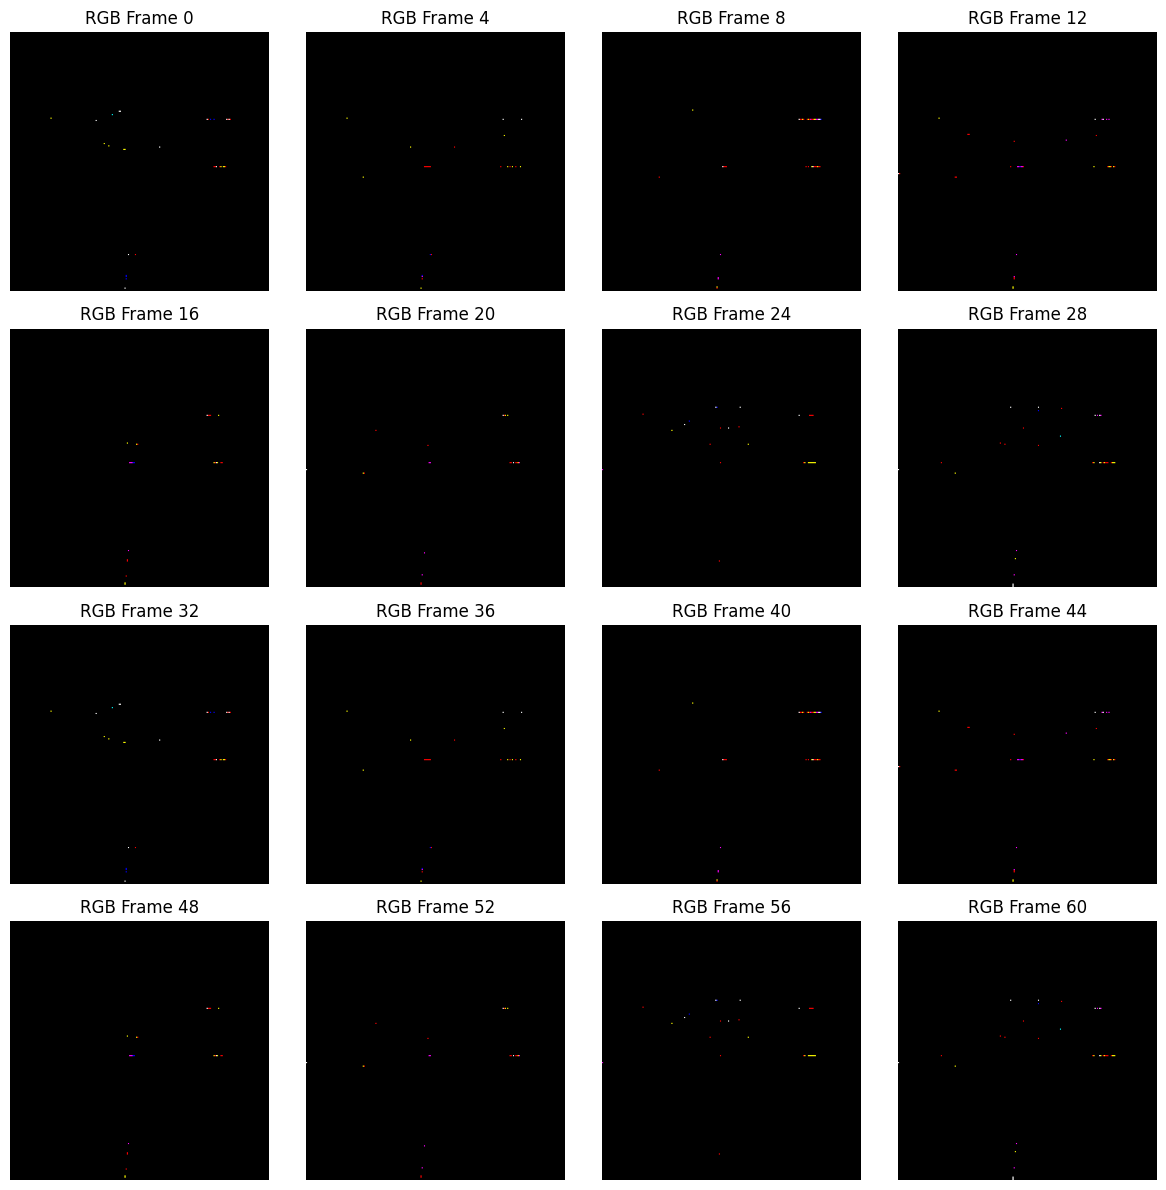

memmap([[[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],

         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],

         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]]],


        [[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0.

In [9]:
data = visualize_nii_images('G:\\test.nii', num_frames=32, num_channels=3, size=(224, 224))
data